In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

# Load dataset
df = pd.read_csv('Sample - Superstore.csv', encoding='latin-1')

# Check data
print(df.shape)
print(df.columns)
df.head() 

(9994, 21)
Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='str')


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [2]:
conn = sqlite3.connect('superstore.db')
df.to_sql('orders', conn, if_exists='replace', index=False)

query1 = pd.read_sql_query("""
    SELECT Region, 
           ROUND(SUM(Sales), 2) as Total_Sales
    FROM orders
    GROUP BY Region
    ORDER BY Total_Sales DESC
""", conn)

print("=== SALES BY REGION ===")
print(query1)

=== SALES BY REGION ===
    Region  Total_Sales
0     West    725457.82
1     East    678781.24
2  Central    501239.89
3    South    391721.91


In [3]:
query2 = pd.read_sql_query("""
    SELECT Category,
           ROUND(SUM(Profit), 2) as Total_Profit,
           ROUND(SUM(Sales), 2) as Total_Sales
    FROM orders
    GROUP BY Category
    ORDER BY Total_Profit DESC
""", conn)

print("=== PROFIT BY CATEGORY ===")
print(query2)

=== PROFIT BY CATEGORY ===
          Category  Total_Profit  Total_Sales
0       Technology     145454.95    836154.03
1  Office Supplies     122490.80    719047.03
2        Furniture      18451.27    741999.80


In [4]:
query3 = pd.read_sql_query("""
    SELECT [Product Name],
           ROUND(SUM(Sales), 2) as Total_Sales,
           ROUND(SUM(Profit), 2) as Total_Profit
    FROM orders
    GROUP BY [Product Name]
    ORDER BY Total_Sales DESC
    LIMIT 10
""", conn)

print("=== TOP 10 PRODUCTS BY SALES ===")
print(query3)

=== TOP 10 PRODUCTS BY SALES ===
                                        Product Name  Total_Sales  \
0              Canon imageCLASS 2200 Advanced Copier     61599.82   
1  Fellowes PB500 Electric Punch Plastic Comb Bin...     27453.38   
2  Cisco TelePresence System EX90 Videoconferenci...     22638.48   
3       HON 5400 Series Task Chairs for Big and Tall     21870.58   
4         GBC DocuBind TL300 Electric Binding System     19823.48   
5   GBC Ibimaster 500 Manual ProClick Binding System     19024.50   
6               Hewlett Packard LaserJet 3310 Copier     18839.69   
7  HP Designjet T520 Inkjet Large Format Printer ...     18374.90   
8          GBC DocuBind P400 Electric Binding System     17965.07   
9        High Speed Automatic Electric Letter Opener     17030.31   

   Total_Profit  
0      25199.93  
1       7753.04  
2      -1811.08  
3          0.00  
4       2233.51  
5        760.98  
6       6983.88  
7       4094.98  
8      -1878.17  
9       -262.00  


In [5]:
query4 = pd.read_sql_query("""
    SELECT Segment,
           COUNT(DISTINCT [Customer ID]) as Total_Customers,
           ROUND(SUM(Sales), 2) as Total_Sales,
           ROUND(SUM(Profit), 2) as Total_Profit
    FROM orders
    GROUP BY Segment
    ORDER BY Total_Sales DESC
""", conn)

print("=== SALES BY CUSTOMER SEGMENT ===")
print(query4)

=== SALES BY CUSTOMER SEGMENT ===
       Segment  Total_Customers  Total_Sales  Total_Profit
0     Consumer              409   1161401.34     134119.21
1    Corporate              236    706146.37      91979.13
2  Home Office              148    429653.15      60298.68


In [6]:
query5 = pd.read_sql_query("""
    SELECT 
        substr([Order Date], 7, 4) as Year,
        substr([Order Date], 1, 2) as Month,
        ROUND(SUM(Sales), 2) as Monthly_Sales
    FROM orders
    GROUP BY Year, Month
    ORDER BY Year, Month
""", conn)

print("=== MONTHLY SALES TREND ===")
print(query5)

=== MONTHLY SALES TREND ===
    Year Month  Monthly_Sales
0    014    1/        9378.05
1    014    10        3515.01
2    014    11       21431.42
3    014    12       16132.85
4    014    2/        3082.46
..   ...   ...            ...
91  2016    11       60942.49
92  2016    12       63025.01
93  2017    10       53817.55
94  2017    11       79834.19
95  2017    12       47009.72

[96 rows x 3 columns]


In [7]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month

df.to_sql('orders', conn, if_exists='replace', index=False)

query5 = pd.read_sql_query("""
    SELECT 
        Year,
        Month,
        ROUND(SUM(Sales), 2) as Monthly_Sales
    FROM orders
    GROUP BY Year, Month
    ORDER BY Year, Month
""", conn)

print("=== MONTHLY SALES TREND ===")
print(query5)

=== MONTHLY SALES TREND ===
    Year  Month  Monthly_Sales
0   2014      1       14236.90
1   2014      2        4519.89
2   2014      3       55691.01
3   2014      4       28295.35
4   2014      5       23648.29
5   2014      6       34595.13
6   2014      7       33946.39
7   2014      8       27909.47
8   2014      9       81777.35
9   2014     10       31453.39
10  2014     11       78628.72
11  2014     12       69545.62
12  2015      1       18174.08
13  2015      2       11951.41
14  2015      3       38726.25
15  2015      4       34195.21
16  2015      5       30131.69
17  2015      6       24797.29
18  2015      7       28765.33
19  2015      8       36898.33
20  2015      9       64595.92
21  2015     10       31404.92
22  2015     11       75972.56
23  2015     12       74919.52
24  2016      1       18542.49
25  2016      2       22978.82
26  2016      3       51715.88
27  2016      4       38750.04
28  2016      5       56987.73
29  2016      6       40344.53
30  2016   

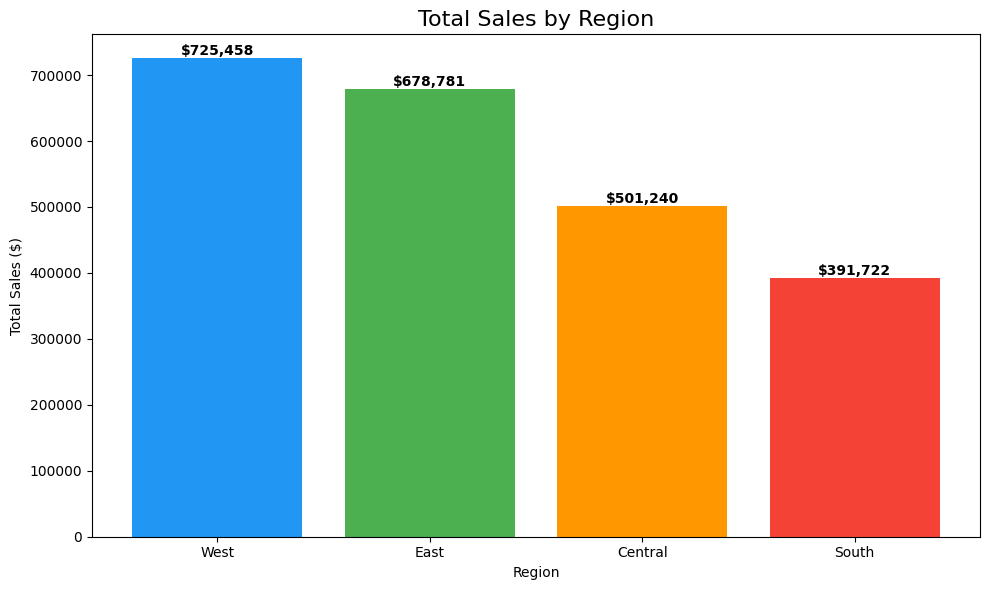

Chart 1 saved!


In [8]:
plt.figure(figsize=(10, 6))
plt.bar(query1['Region'], query1['Total_Sales'], color=['#2196F3', '#4CAF50', '#FF9800', '#F44336'])
plt.title('Total Sales by Region', fontsize=16)
plt.xlabel('Region')
plt.ylabel('Total Sales ($)')
for i, v in enumerate(query1['Total_Sales']):
    plt.text(i, v + 5000, f'${v:,.0f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('sales_by_region.png')
plt.show()
print("Chart 1 saved!")

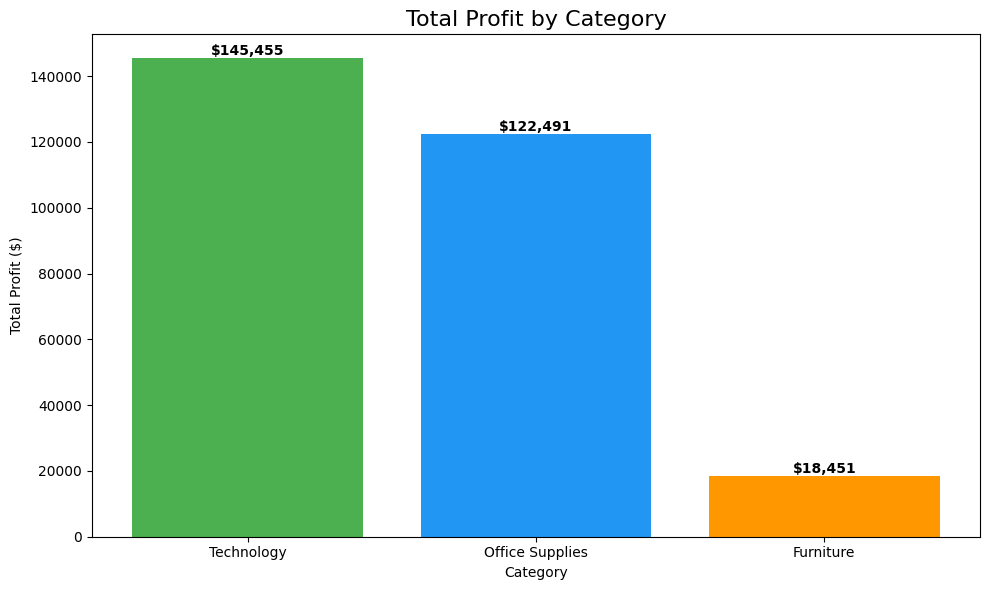

Chart 2 saved!


In [9]:
plt.figure(figsize=(10, 6))
plt.bar(query2['Category'], query2['Total_Profit'], 
        color=['#4CAF50', '#2196F3', '#FF9800'])
plt.title('Total Profit by Category', fontsize=16)
plt.xlabel('Category')
plt.ylabel('Total Profit ($)')
for i, v in enumerate(query2['Total_Profit']):
    plt.text(i, v + 1000, f'${v:,.0f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('profit_by_category.png')
plt.show()
print("Chart 2 saved!")

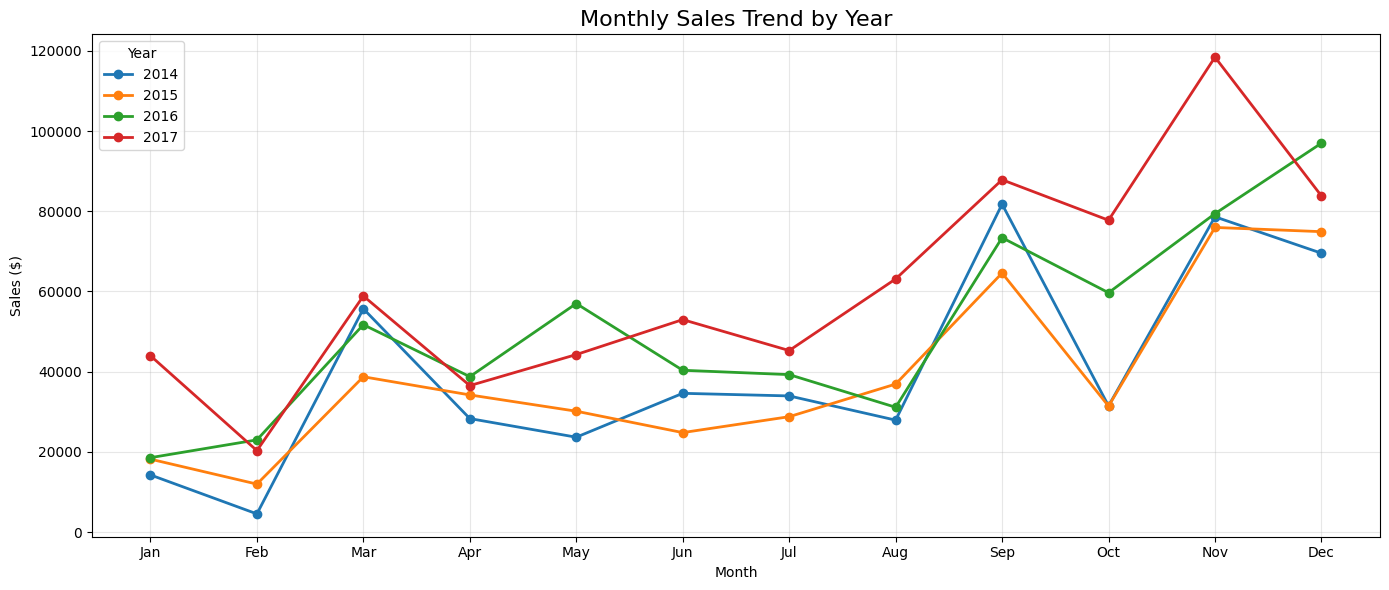

Chart 3 saved!


In [10]:
plt.figure(figsize=(14, 6))
for year in query5['Year'].unique():
    yearly_data = query5[query5['Year'] == year]
    plt.plot(yearly_data['Month'], 
             yearly_data['Monthly_Sales'], 
             marker='o', 
             label=str(year),
             linewidth=2)
plt.title('Monthly Sales Trend by Year', fontsize=16)
plt.xlabel('Month')
plt.ylabel('Sales ($)')
plt.legend(title='Year')
plt.xticks(range(1, 13), ['Jan','Feb','Mar','Apr','May',
                           'Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('monthly_trend.png')
plt.show()
print("Chart 3 saved!")


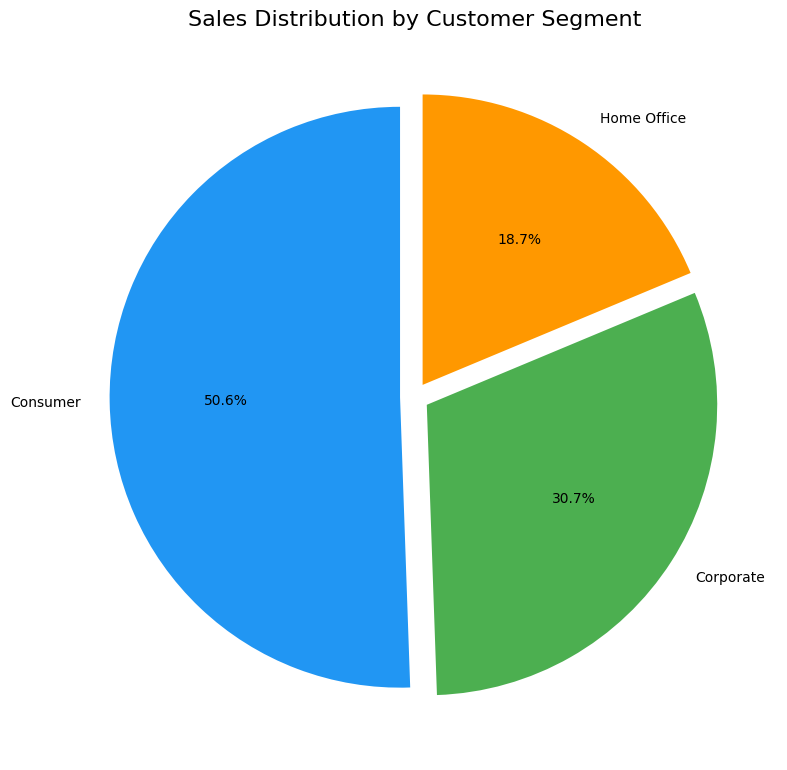

Chart 4 saved!


In [11]:
plt.figure(figsize=(8, 8))
plt.pie(query4['Total_Sales'], 
        labels=query4['Segment'],
        autopct='%1.1f%%',
        colors=['#2196F3', '#4CAF50', '#FF9800'],
        startangle=90,
        explode=(0.05, 0.05, 0.05))
plt.title('Sales Distribution by Customer Segment', fontsize=16)
plt.tight_layout()
plt.savefig('segment_distribution.png')
plt.show()
print("Chart 4 saved!")